In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import CubicSpline
from scipy.integrate import romb
import astropy.units as u

from darksirenpop.mock.make_mock_gws import sample_v90, v90_to_sigma, Config, z_dist_alt, z_dist_agn
from darksirenpop.utilities.utils import sample_spherical_angles, spherical2cartesian, cartesian2spherical, make_nice_plots
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.redshift_utils import fast_z_at_value

make_nice_plots()

In [2]:
pdet_path = '/home/lucas/Documents/PhD/darksirenpop/mock/pdet'

def make_config(ngw, zcut):
    return Config(
    RUN_ID=0,
    AGNDIST='46.5',
    NGW=ngw,
    ZCUT=zcut
)


Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


100%|██████████| 100/100 [00:00<00:00, 519.94it/s]


3.796125003513636e-05 0.002813588395673895
Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


100%|██████████| 100/100 [00:00<00:00, 532.52it/s]


0.0001522508558231947 0.006824445517394416
Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


...

0.004159780832162012 0.05392880987825823
Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


100%|██████████| 100/100 [00:00<00:00, 537.07it/s]


0.007802979417343934 0.07277961712426458
Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


100%|██████████| 100/100 [00:00<00:00, 525.18it/s]


0.014106449739983538 0.0978659909002927


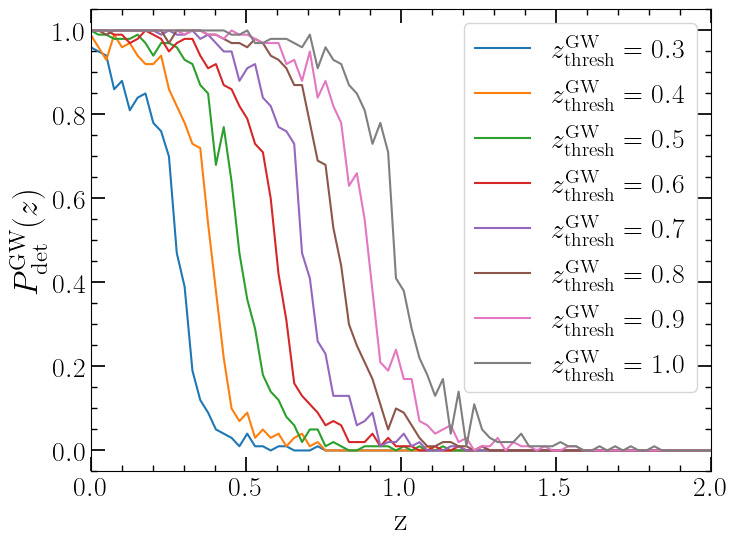

In [3]:
z_true_arr = np.linspace(0, 2.5, 100)
Ngw_per_z = 100  # Number of GWs to inject at each redshift, increase number for smoother selection function
zcuts = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

plt.figure(figsize=(8,6))
for zcut in zcuts:
    cfg = make_config(Ngw_per_z, zcut)

    Pdet_arr = np.zeros_like(z_true_arr)
    for i, redshift_true in tqdm(enumerate(z_true_arr), total=len(z_true_arr)):
        true_theta, true_phi = sample_spherical_angles(n_samps=Ngw_per_z)
        true_redshift = np.tile(redshift_true, Ngw_per_z)
        true_rcom = COSMO.comoving_distance(true_redshift).value

        true_x, true_y, true_z = spherical2cartesian(true_rcom, true_theta, true_phi)

        v90 = sample_v90(Ngw_per_z, config=cfg)
        sig = v90_to_sigma(v90)
        obs_x, obs_y, obs_z = np.random.normal(loc=true_x, scale=sig, size=Ngw_per_z), np.random.normal(loc=true_y, scale=sig, size=Ngw_per_z), np.random.normal(loc=true_z, scale=sig, size=Ngw_per_z)
        obs_rcom, _, _ = cartesian2spherical(obs_x, obs_y, obs_z)
        obs_redshift = fast_z_at_value(COSMO.comoving_distance, obs_rcom * u.Mpc)
        sel = obs_redshift < zcut

        Pdet_arr[i] = np.sum(sel) / Ngw_per_z

    # np.save(f'{pdet_path}/pdet_z_{zcut}.npy', np.array([z_true_arr, Pdet_arr]))

    plt.plot(z_true_arr, Pdet_arr, label=fr'$z_{{\rm thresh}}^{{\rm GW}} = {zcut}$')

    int_ax = np.linspace(1e-6, 10, 16*1024+1)
    Pdet = CubicSpline(z_true_arr, Pdet_arr, extrapolate=False)(int_ax)
    Pdet[np.isnan(Pdet)] = 0  # NaNs outside extrapolation range changed to zeros

    alpha_agn = romb(Pdet * z_dist_agn(int_ax, config=cfg), dx=np.diff(int_ax)[0])
    alpha_alt = romb(Pdet * z_dist_alt(int_ax, config=cfg), dx=np.diff(int_ax)[0])
    print(alpha_agn, alpha_alt)

plt.xlim(0, 2)
plt.xlabel(r'z')
plt.ylabel(r'$P_{\rm det}^{\rm GW}(z)$')
plt.legend()
plt.show()
